C:\Users\Sujal shrestha\AppData\Local\Temp\ipykernel_7540\1102954523.py:15: DtypeWarning: Columns (2,3,4,5,6,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Corona-Data.csv",quotechar='"',sep=',')


Rows of the Data:278848
Columns of the Data:11


Missing Values of the Specific Table:
Missing Values :Cough_symptoms            252
Fever                     252
Sore_throat                 1
Shortness_of_breath         1
Headache                    1
Age_60_above           127320
dtype: int64


Specific Columns Remove:        Ind_ID   Test_date Cough_symptoms  Fever Sore_throat  \
4512      4513  17-03-2020          False  False       False   
4513      4514  17-03-2020          False  False       False   
4514      4515  17-03-2020          False  False       False   
4515      4516  17-03-2020          False  False       False   
4516      4517  17-03-2020          False  False       False   
...        ...         ...            ...    ...         ...   
156035  156036  14-04-2020           True  False        True   
156036  156037  14-04-2020           True  False        True   
156037  156038  14-04-2020           True   True       False   
156038  156039  14-04-2020          Fa

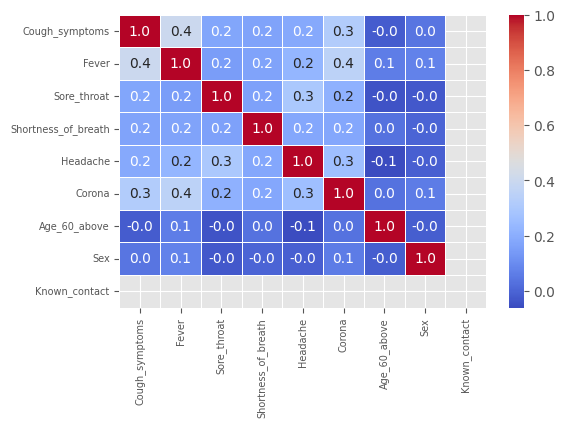



Dropping The Age Columns:
        Cough_symptoms  Fever  Sore_throat  Shortness_of_breath  Headache  \
13730             True   True        False                False     False   
13748             True   True        False                False     False   
13752             True   True        False                False     False   
13765             True   True        False                False     False   
13768             True  False        False                 True     False   
...                ...    ...          ...                  ...       ...   
119146           False  False        False                False     False   
88125            False  False        False                False     False   
188808           False  False        False                False     False   
172715           False  False        False                False     False   
109952           False  False        False                False     False   

        Corona  Sex  Known_contact  
13730     

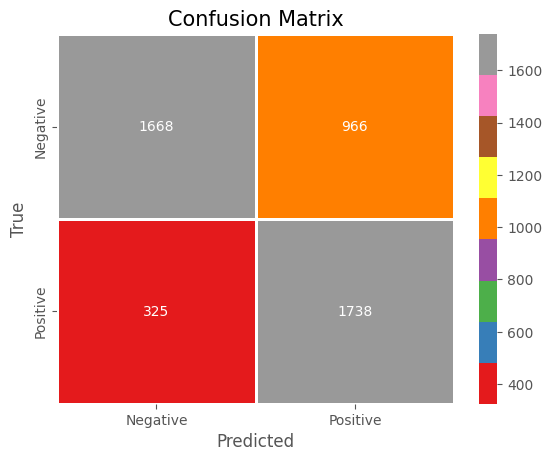

              precision    recall  f1-score   support

           0       0.63      0.84      0.72      1993
           1       0.84      0.64      0.73      2704

    accuracy                           0.73      4697
   macro avg       0.74      0.74      0.73      4697
weighted avg       0.75      0.73      0.73      4697



In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from matplotlib.pyplot import xticks
from matplotlib.pyplot import yticks
plt.style.use('ggplot')

#ML Model
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix,accuracy_score

#importing the DataSet
df = pd.read_csv("Corona-Data.csv",quotechar='"',sep=',')
# df[0] = df[0].str.replace('"', '',regex=False)
# df = df[0].str.split(",", expand=True)
# df.columns = [
#     'Ind_ID',
#     'Test_date',
#     'Cough_symptoms',
#     'Fever',
#     'Sore_throat',
#     'Shortness_of_breath',
#     'Headache',
#     'Corona',
#     'Age_60_above',
#     'Sex',
#     'Known_contact'
# ]
# df = df[df['Ind_ID'] != 'Ind_ID']
# df.to_csv("Fixed-Corona.csv", index=False)
df.head()
r,c=df.shape
print(f"Rows of the Data:{r}")
print(f"Columns of the Data:{c}")
print("\n")

#Identify the Wrong Columns
cols_to_fix=df.columns[[2,3,4,5,6,8]]
print("Missing Values of the Specific Table:")
null=df[cols_to_fix].isnull().sum()
print(f"Missing Values :{null}")
print("\n")

#Removing Specific Columns
cols_to_remove=df.columns[[2,3,4,5,6,8]]
drop_value=df.dropna(subset=cols_to_remove)
print(f"Specific Columns Remove:{drop_value}")
print(f"Final High Quality Row:{df.shape[0]}")
print("\n")

age_60_above=df.dropna(subset=['Age_60_above'])
print(f"Dropping The Values of 60 above :{age_60_above}")

#Final Re-Checking the Null Value
final_null=df[cols_to_remove].isnull().sum()
print(f"Final Missing Values:{final_null}")
print("\n")
print(df.head())
print("\n")
print(df.info())

#Mapping The Values
symptoms_map={"True":1,"False":0,True:1,False:0}
symptoms_cols=['Cough_symptoms','Fever','Sore_throat','Shortness_of_breath','Headache','Known_contact']
for symp in symptoms_cols:
    df[symp]=df[symp].map(symptoms_map).astype('bool')
print(df.info())
print("\n")
print(df[symptoms_cols].isnull().sum())

#Final Checking of Corona Columns
corona_val_count=df['Corona'].value_counts()
print(f"Counting The Values of Corona:\n{corona_val_count}")
print("\n")
corona_value=df[df['Corona']!='other']
print(f"Final Corona Values:\n{corona_value}")

df1=df[df['Corona']=='positive']
df2=df[df['Corona']=='negative'].sample(frac=1,random_state=42).iloc[0:10626]
data=pd.concat([df1,df2],axis=0)
print(f"Final Data For Corona Columns:\n{data}")

#Fixing The Working Columns
data=data.iloc[:,2:]
print(f"Final Columns of the Data:\n{data}")
print("\n")

#Counting the Known Contact Columns
known_contact=data['Known_contact'].value_counts()
print(f"Counting The Known Contact:\n{known_contact}")
print("\n")

#Counting the Sex Columns
sex=data['Sex'].value_counts()
print(f"Counting The Sex Columns:\n{sex}")
print("\n")

#Counting The Age_60_above
age=data['Age_60_above'].value_counts()
print(f"Counting The Value of Age 60 above:\n{age}")
print("\n")

#Final Checking the Null Values
check_null=data.isnull().sum()
print(f"Checking Null Value of The Data:\n{check_null}")
print("\n")
data=data.dropna(subset=['Sex'])
final_null=data.isnull().sum()
print(f"Final Null Value of the Data:\n{final_null}")
print("\n")

#Importing The Ordinal Encoding 
from sklearn.preprocessing import OrdinalEncoder

columns_enc = ['Age_60_above', 'Sex', 'Known_contact']

for enc in columns_enc:
    if data[enc].isnull().all():
        print(f"{enc} is empty")
        continue

    encoder = OrdinalEncoder()
    data[[enc]] = encoder.fit_transform(data[[enc]])
print(data.head())
print(data.info())
print("\n")
print(data.shape)
print("\n")
print(data.isnull().sum())
print("/n")
print(data.head())

#Lable Encoding For y 
from sklearn.preprocessing import LabelEncoder
print("Label Encoding")
le=LabelEncoder()
data['Corona']=le.fit_transform(data['Corona'])
print(f"Corona Encoding:{le.classes_}")
print(f"Corona value counts: {data['Corona'].value_counts()}")

#Now Model Traning and Testing Part
#Correlation of the DataSet
print(data.corr())
 
#Plotting The heatmap
corr=data.corr()
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".1f",linewidth=0.5)
plt.tight_layout()
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.show()
print('\n')

#Dropping The Age_60_above 
data=data.drop(columns=['Age_60_above'],axis=1)
print(f"Dropping The Age Columns:\n{data}")

#Traning and Testing The Data
X=data[['Cough_symptoms','Fever','Sore_throat', 'Shortness_of_breath', 'Headache', 'Known_contact']]
y=data['Corona']
X_train,X_test,y_train,y_test=train_test_split(X,y , train_size=0.80,test_size=0.20,random_state=42)

#importing the SVC
from sklearn.svm import SVC
svc=SVC()
svc.fit(X_train,y_train)

#Creating The Pickle File
import pickle
with open("Corona.pickle","wb") as f:
    pickle.dump(svc,f)
print(y_test)

y_pred=svc.predict(X_test)
print(y_pred)
print("\n")
print(y_test)

#Svc Test Accuracy
svc_accuracy=round(accuracy_score(y_test,y_pred)*100,2)
print(f"Accuracy Score of an Testing Data:{svc_accuracy}")
print("\n")

#SVC Train Accuracy
y_train_pred=svc.predict(X_train)
print(data.columns)
print(y_train_pred)
svc_train_accuracy=round(accuracy_score(y_train,y_train_pred)*100,2)
print(f"Accuracy Score of an Training Data:{svc_train_accuracy} ")
print("\n")

#Cough_symptoms	Fever	Sore_throat	Shortness_of_breath	Headache	Known_contact
Cough_symptoms = int(input("Cough_symptoms Enter 1 for True 0 for False = "))
Fever = int(input(" Fever Enter 1 for True 0 for False = "))
Sore_throat = int(input("Sore_throat Enter 1 for True 0 for False ="))
Shortness_of_breath = int(input("Shortness_of_breath Enter 1 for True 0 for False = "))
Headache = int(input("Headache Enter 1 for True 0 for False = "))
# Sex = int(input("Sex Enter 1 for Male 0 for Female = "))
Known_contact = int(input("0 for Abroad 1 for Contact with confirmed 2 for Other = "))


new_data = {'Cough_symptoms':[Cough_symptoms],
            'Fever':[Fever],
            'Sore_throat':[Sore_throat],
            'Shortness_of_breath':[Shortness_of_breath],
            'Headache':[Headache],
            # 'Sex':[Sex],
            'Known_contact':[Known_contact]
            }
d = pd.DataFrame(new_data)
print("------Corona Classification------")
print("\n")
print(d)
print("\n")

#Classifying the Corona of an User
y_score=svc.predict(d)
res=le.inverse_transform(y_score)
print(res)
#Checking the Positive or negative
if res[0]=="positive":
    print("You are Corona Positive , Take Care Bro !")
else:
    print("Congrat,You are Safe Bro !")

print("\n")
#Confusing Matrix
y_pred=svc.predict(X_test)
print(y_pred)
print("\n")
print(y_pred.shape)
print("\n")

cm=confusion_matrix(y_pred,y_test)
print(cm)
print("\n")

class_label=['Negative','Positive']
df_cm=pd.DataFrame(cm,index=class_label,columns=class_label)
print(df_cm)
sns.heatmap(df_cm,annot=True,cmap='Set1',linewidths=1,fmt='d')
plt.title("Confusion Matrix",fontsize=15)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

#Classification Report
from sklearn.metrics import classification_report, confusion_matrix
ytest=np.array(y_test)
print(classification_report(ytest,y_pred))
